In [1]:
# new fresh data set

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv(
    "Dataset/student_productivity_distraction_dataset_20000.csv"
)
# load the dataset

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,20000.0,10000.500000,5773.647028,1.0,5000.7500,10000.500,15000.2500,20000.00
age,20000.0,23.007450,3.754890,17.0,20.0000,23.000,26.0000,29.00
study_hours_per_day,20000.0,5.254562,2.742876,0.5,2.9000,5.250,7.6400,10.00
sleep_hours,20000.0,6.517799,2.029784,3.0,4.7700,6.510,8.3100,10.00
phone_usage_hours,20000.0,6.250479,3.313082,0.5,3.3800,6.240,9.1025,12.00
social_media_hours,20000.0,4.003655,2.305154,0.0,2.0000,4.010,5.9700,8.00
youtube_hours,20000.0,2.990177,1.729815,0.0,1.4875,2.980,4.4800,6.00
gaming_hours,20000.0,2.988339,1.732803,0.0,1.4900,2.970,4.4900,6.00
breaks_per_day,20000.0,7.542400,4.016231,1.0,4.0000,8.000,11.0000,14.00
coffee_intake_mg,20000.0,249.654550,143.711231,0.0,125.0000,249.000,373.0000,499.00


In [5]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [6]:
df.info()
# check the data types and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [7]:
df.duplicated().sum() 
# check for duplicate rows  

np.int64(0)

In [8]:
df.isnull().sum()  
# check for missing values or null values in the dataset 

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [9]:
df = df.drop(
    "student_id",
    axis=1
)
# drop the student_id column as it is not useful for analysis

In [10]:
df.describe()   
# statistical summary of the dataset

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [11]:
df["gender"].value_counts()
# check the distribution of gender like male and female

gender
Female    9640
Male      9582
Other      778
Name: count, dtype: int64

In [12]:
df["gender"].unique()
# check the unique values of gender

array(['Female', 'Male', 'Other'], dtype=object)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(
    df["gender"]
)
# enconding the gender

In [14]:
print(le.classes_ )

['Female' 'Male' 'Other']


In [15]:
print(df.columns)

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')


In [16]:
corr = df.corr(numeric_only=True)

print(corr['productivity_score'].sort_values(ascending=False))

# mainly checking the correlation of productivity score with other features in the dataset
# because with that only we can predict what is closely related

productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
coffee_intake_mg         0.010190
gender                   0.003703
exercise_minutes         0.002892
final_grade              0.001954
social_media_hours       0.001285
gaming_hours             0.000685
youtube_hours           -0.000224
assignments_completed   -0.001757
age                     -0.005423
breaks_per_day          -0.005836
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


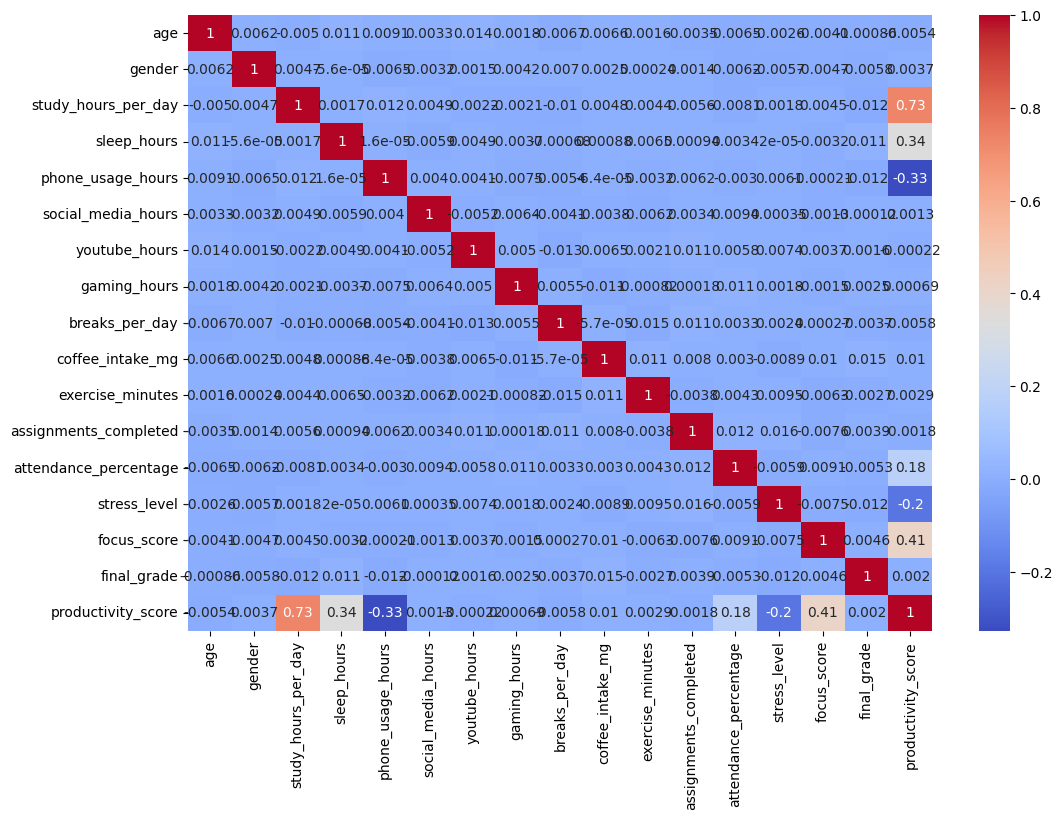

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()
# since prev datasets are a failure i have analysed this ds using heatmap for better visualization and understanding of correlation between features and target variable

In [18]:
X = df.drop(
    'productivity_score',
    axis=1
)
# input features

y = df['productivity_score']
# output feature

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# training testing spliting of the dataset

In [20]:
model = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    # jobs=-1 coz this will help in utilising full cpu power for training the model 
    random_state=42
)

model.fit(X_train, y_train)
# since ds is conti regression model is used

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)
# performance of the model is evaluated using r2 score in regressionwhich is 0.9749... which is very good and model is performing well

0.9749190048786347


In [23]:
# checking feature importance to understand which features are more important for predicting productivity score for viva tis will  help


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
2     study_hours_per_day    0.540231
14            focus_score    0.163811
3             sleep_hours    0.113333
4       phone_usage_hours    0.108373
13           stress_level    0.027671
12  attendance_percentage    0.027513
15            final_grade    0.002334
5      social_media_hours    0.002316
9        coffee_intake_mg    0.002301
6           youtube_hours    0.002284
7            gaming_hours    0.002242
10       exercise_minutes    0.002160
11  assignments_completed    0.001799
8          breaks_per_day    0.001633
0                     age    0.001556
1                  gender    0.000441


In [24]:
# if classification we use accuracy score ,f1,precision and confusion matrix
#  but since this is regression we use r2 score and mean absolute error and mean squared error for evaluation of the model performance

In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

2.000613525


In [26]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print(rmse)

2.5417780881112537


In [27]:
# saving the model using joblib so that we can use it in future without training again and again

import joblib

joblib.dump(
    model,
    "model/productivity_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [28]:
# verifying the saved model by loading it 
loaded_model = joblib.load(
    "model/productivity_model.pkl"
)

print(loaded_model)

RandomForestRegressor(n_jobs=-1, random_state=42)


In [29]:
import joblib

joblib.dump(
    le,
    "model/gender_encoder.pkl"
)

print("Gender Encoder Saved")

Gender Encoder Saved


In [30]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# lr = LinearRegression()

# lr.fit(X_train, y_train)

# y_pred_lr = lr.predict(X_test)

# r2_lr = r2_score(y_test, y_pred_lr)

# print("Linear Regression R²:", r2_lr)
# DONT USE LINEAR REGRESSION AS IT IS NOT SUITABLE FOR THIS DATASET AND WILL GIVE POOR PERFORMANCE

In [31]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("Decision Tree R²:", r2_dt)
# DECISION TREE REGRESSOR IS ALSO NOT SUITABLE FOR THIS DATASET AND WILL GIVE POOR PERFORMANCE

Decision Tree R²: 0.9031962957854879


In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("XGBoost R²:", r2_xgb)
# XGBoost Regressor is suitable BUT RANDOM WILL GIVE ACCURATE RESULTS

# XGBoost achieved a slightly higher R² score. 
# However, Random Forest was selected because it provides good performance 
# while being easier to interpret, explain, and analyze. 
# It also provides feature importance rankings that helped identify 
# the key factors affecting student productivity. Since the performance 
# difference was not significant for the project requirements, Random 
# Forest was chosen as the final model.

# The dataset is structured tabular data. Random Forest performs very well on tabular datasets, reduces overfitting through ensemble learning, provides feature importance analysis, and achieved an R² score of 97.49%, which was sufficient for the application's requirements.

XGBoost R²: 0.9952937650089652


In [33]:
print(df.columns)

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')


In [34]:
df[['productivity_score']].describe()

,productivity_score
count,20000.000000
mean,50.180419
std,16.086666
min,0.000000
25%,38.700000
50%,50.235000
75%,61.782500
max,100.000000


In [35]:
print(X.columns)

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade'],
      dtype='object')


In [36]:
corr = df.corr(numeric_only=True)

print(
    corr["productivity_score"]
    .sort_values(ascending=False)
)

productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
coffee_intake_mg         0.010190
gender                   0.003703
exercise_minutes         0.002892
final_grade              0.001954
social_media_hours       0.001285
gaming_hours             0.000685
youtube_hours           -0.000224
assignments_completed   -0.001757
age                     -0.005423
breaks_per_day          -0.005836
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


In [37]:
print(X.columns)

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade'],
      dtype='object')


In [38]:
print(df.describe().T[['min','max']])

                        min     max
age                    17.0   29.00
gender                  0.0    2.00
study_hours_per_day     0.5   10.00
sleep_hours             3.0   10.00
phone_usage_hours       0.5   12.00
social_media_hours      0.0    8.00
youtube_hours           0.0    6.00
gaming_hours            0.0    6.00
breaks_per_day          1.0   14.00
coffee_intake_mg        0.0  499.00
exercise_minutes        0.0  119.00
assignments_completed   0.0   19.00
attendance_percentage  40.0  100.00
stress_level            1.0   10.00
focus_score            30.0   99.00
final_grade            40.0   99.99
productivity_score      0.0  100.00


In [39]:
df.head()
df.describe()

,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.00745,0.556900,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,3.75489,0.569718,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,17.00000,0.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,20.00000,0.000000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,23.00000,1.000000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,26.00000,1.000000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,29.00000,2.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [40]:
print(model)

RandomForestRegressor(n_jobs=-1, random_state=42)


In [41]:
joblib.dump(
    model,
    "model/productivity_model.pkl",
    compress=3
)

['model/productivity_model.pkl']